# Las olas de calor llegan antes y se van después

**¿Cuántos días separan la primera ola de calor del año de la última?** En tierra firme, a mediados de los 80, unos 33. A mediados de los 2010, casi 61.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Xu et al. (2026). *Earlier and faster heatwave onset on land under a warming climate*. **Nature Climate Change**.
**DOI:** [10.1038/s41558-026-02762-2](https://doi.org/10.1038/s41558-026-02762-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-23-olas-de-calor-antes-y-mas-largas/notebook.ipynb)

**Video:** Pendiente

## ¿Qué midieron?

El equipo de Xu revisó 45 años (1979–2023) de temperatura máxima diaria en toda la tierra firme salvo la Antártida, usando ERA5: un reanálisis, es decir, una reconstrucción del clima que combina observaciones con un modelo del tiempo, en una rejilla de unos 28 km. Una **ola de calor** es al menos 3 días seguidos con la máxima por encima del percentil 90 de su época del año (más caliente que 9 de cada 10 días de esas fechas). Para cada punto y cada año miraron tres cosas: cuándo **empieza** la primera ola, cuándo **termina** la última y cuántos días hay entre ambas, la **temporada**. La búsqueda se hace dentro de una ventana fija: de mayo a septiembre en el hemisferio norte y de noviembre a marzo en el sur.

Los autores publicaron en Figshare sus medias móviles de 15 años (cada valor promedia 15 años seguidos: 1979–1993, 1980–1994…), los mapas de tendencia y el código del detector. Con eso podemos rehacer las cifras.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ZONA = 'Global'              # 'Global', 'Hiperárida', 'Árida', 'Semiárida', 'Subhúmeda seca' o 'Húmeda'
FUENTE = 'Fuente: Xu et al. (2026), Nature Climate Change | Datos: Figshare 10.6084/m9.figshare.30843515 (ERA5)'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO = '#BBBBBB'

import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-09-23-olas-de-calor-antes-y-mas-largas'
ARCHIVOS = ['tendencias_15a_por_zona.csv', 'resumen_fracciones_tierra.csv',
            'histograma_tendencias_celdas.csv', 'tipos_inicio_primera_ola.csv',
            'tmax_diaria_estaciones_era5.csv', 'olas_por_anio_estaciones_autores.csv',
            'estaciones.csv', 'mapa_tendencias_1grado.csv']
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for a in ARCHIVOS:
    if not os.path.exists(f'datos/{a}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{a}', f'datos/{a}')

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Números en formato español: coma decimal, punto de miles
def es(x):
    s = str(x)
    s = re.sub(r'(?<=\d)\.(?=\d)', ',', s)
    s = re.sub(r'(\d)e\+?(-?)0*(\d+)', r'\1×10^\2\3', s)
    return s.replace('_', '.')

def pr(*a):
    print(*[es(x) for x in a])

# Pendiente por mínimos cuadrados, en días por década, con su error estándar
def tendencia(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    res = y - (a + b * x)
    se = np.sqrt(res @ res / (len(x) - 2) / ((x - x.mean()) @ (x - x.mean())))
    return 10 * b, 10 * se

zonas = pd.read_csv('datos/tendencias_15a_por_zona.csv')
fracc = pd.read_csv('datos/resumen_fracciones_tierra.csv')
hist = pd.read_csv('datos/histograma_tendencias_celdas.csv')
tipos = pd.read_csv('datos/tipos_inicio_primera_ola.csv')
tmax = pd.read_csv('datos/tmax_diaria_estaciones_era5.csv')
olas_aut = pd.read_csv('datos/olas_por_anio_estaciones_autores.csv')
estaciones = pd.read_csv('datos/estaciones.csv')

pr(f'Medias móviles de 15 años: {len(zonas)} filas, ventanas centradas en {zonas.anio_centro_ventana15.min()}–{zonas.anio_centro_ventana15.max()}')
print('Zonas:', ', '.join(zonas.zona.unique()))
pr(f'Temperatura diaria: {len(tmax):_} días × {len(estaciones)} estaciones de prueba')

Medias móviles de 15 años: 186 filas, ventanas centradas en 1986–2016
Zonas: Hiperárida, Árida, Semiárida, Subhúmeda seca, Húmeda, Global
Temperatura diaria: 16.425 días × 5 estaciones de prueba


Aquí está.

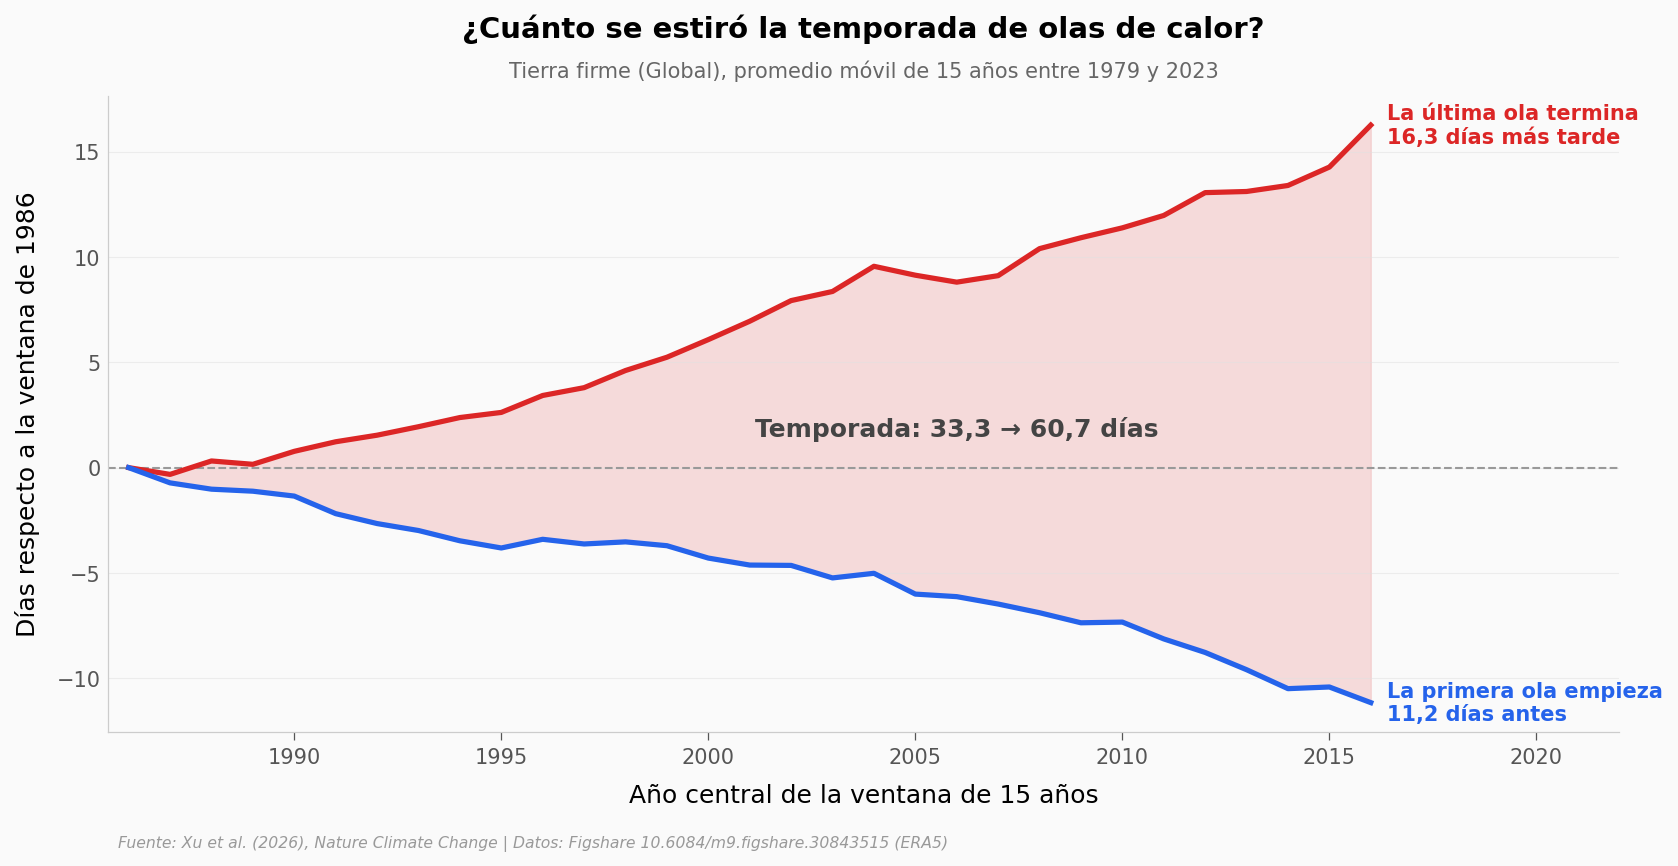

Inicio: -3,29 ± 0,12 días por década
Final: +5,41 ± 0,12 días por década
Temporada: +8,71 ± 0,17 días por década
Temporada ventana 2016 / ventana 1986: ×1,82


In [2]:
g = zonas[zonas.zona == ZONA].sort_values('anio_centro_ventana15')
x = g.anio_centro_ventana15.values
ini0, fin0 = g.inicio_dia_del_anio.iloc[0], g.fin_dia_del_anio.iloc[0]
d_ini = g.inicio_dia_del_anio.values - ini0
d_fin = g.fin_dia_del_anio.values - fin0

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.fill_between(x, d_ini, d_fin, color=COLOR_ALERTA, alpha=0.15, zorder=1)
ax.plot(x, d_fin, color=COLOR_ALERTA, lw=2.5, zorder=3)
ax.plot(x, d_ini, color=COLOR_DATOS, lw=2.5, zorder=3)
ax.axhline(0, color='#999999', lw=1, ls='--')
ax.text(x[-1] + 0.4, d_fin[-1], f'La última ola termina\n{es(round(d_fin[-1], 1))} días más tarde',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', va='center')
ax.text(x[-1] + 0.4, d_ini[-1], f'La primera ola empieza\n{es(round(-d_ini[-1], 1))} días antes',
        color=COLOR_DATOS, fontsize=10, fontweight='bold', va='center')
t0, t1 = g.temporada_dias.iloc[0], g.temporada_dias.iloc[-1]
ax.text(2006, 1.5, f'Temporada: {es(round(t0, 1))} → {es(round(t1, 1))} días',
        fontsize=12, fontweight='bold', color='#444444', ha='center')
ax.set_xlim(x[0] - 0.5, x[-1] + 6)
ax.set_xlabel('Año central de la ventana de 15 años')
ax.set_ylabel('Días respecto a la ventana de 1986')
ax.set_title('¿Cuánto se estiró la temporada de olas de calor?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Tierra firme ({ZONA}), promedio móvil de 15 años entre 1979 y 2023',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/temporada_global.png', dpi=200, bbox_inches='tight')
plt.show()

for col, nombre in [('inicio_dia_del_anio', 'Inicio'), ('fin_dia_del_anio', 'Final'), ('temporada_dias', 'Temporada')]:
    b, se = tendencia(x, g[col])
    pr(f'{nombre}: {b:+.2f} ± {se:.2f} días por década')
pr(f'Temporada ventana 2016 / ventana 1986: ×{t1 / t0:.2f}')

La primera ola del año llega cada vez antes: **3,29 ± 0,12 días por década**. La última se va cada vez más tarde: **5,41 ± 0,12 días por década**. En conjunto, la temporada se alarga **8,71 ± 0,17 días por década**, y las tres cifras coinciden con el abstract al centésimo.

Entre la ventana centrada en 1986 y la de 2016, el inicio se adelanta 11,2 días y el final se retrasa 16,3: la temporada pasa de **33,3 a 60,7 días**, 1,82 veces más larga. El verano de las olas crece más por la cola que por la cabeza.

Dos cosas que conviene tener en mente:

- **El ± es optimista.** La recta se ajusta sobre 31 medias móviles de 15 años que se solapan entre sí, no sobre 45 años independientes. La dirección es clarísima; la precisión del segundo decimal, no tanto.
- **No es una fecha del calendario.** El "día del año" promedia el hemisferio norte y el sur, que buscan sus olas en ventanas distintas. Por eso hablamos de días de diferencia y no de "finales de junio".

## ¿Cambia igual en todas partes?

Los autores dicen que las **zonas secas** (*drylands*) cambiaron más que las húmedas. Las clasifican por aridez en cuatro niveles secos y uno húmedo. ¿Se cumple para el inicio, el final y la temporada a la vez?

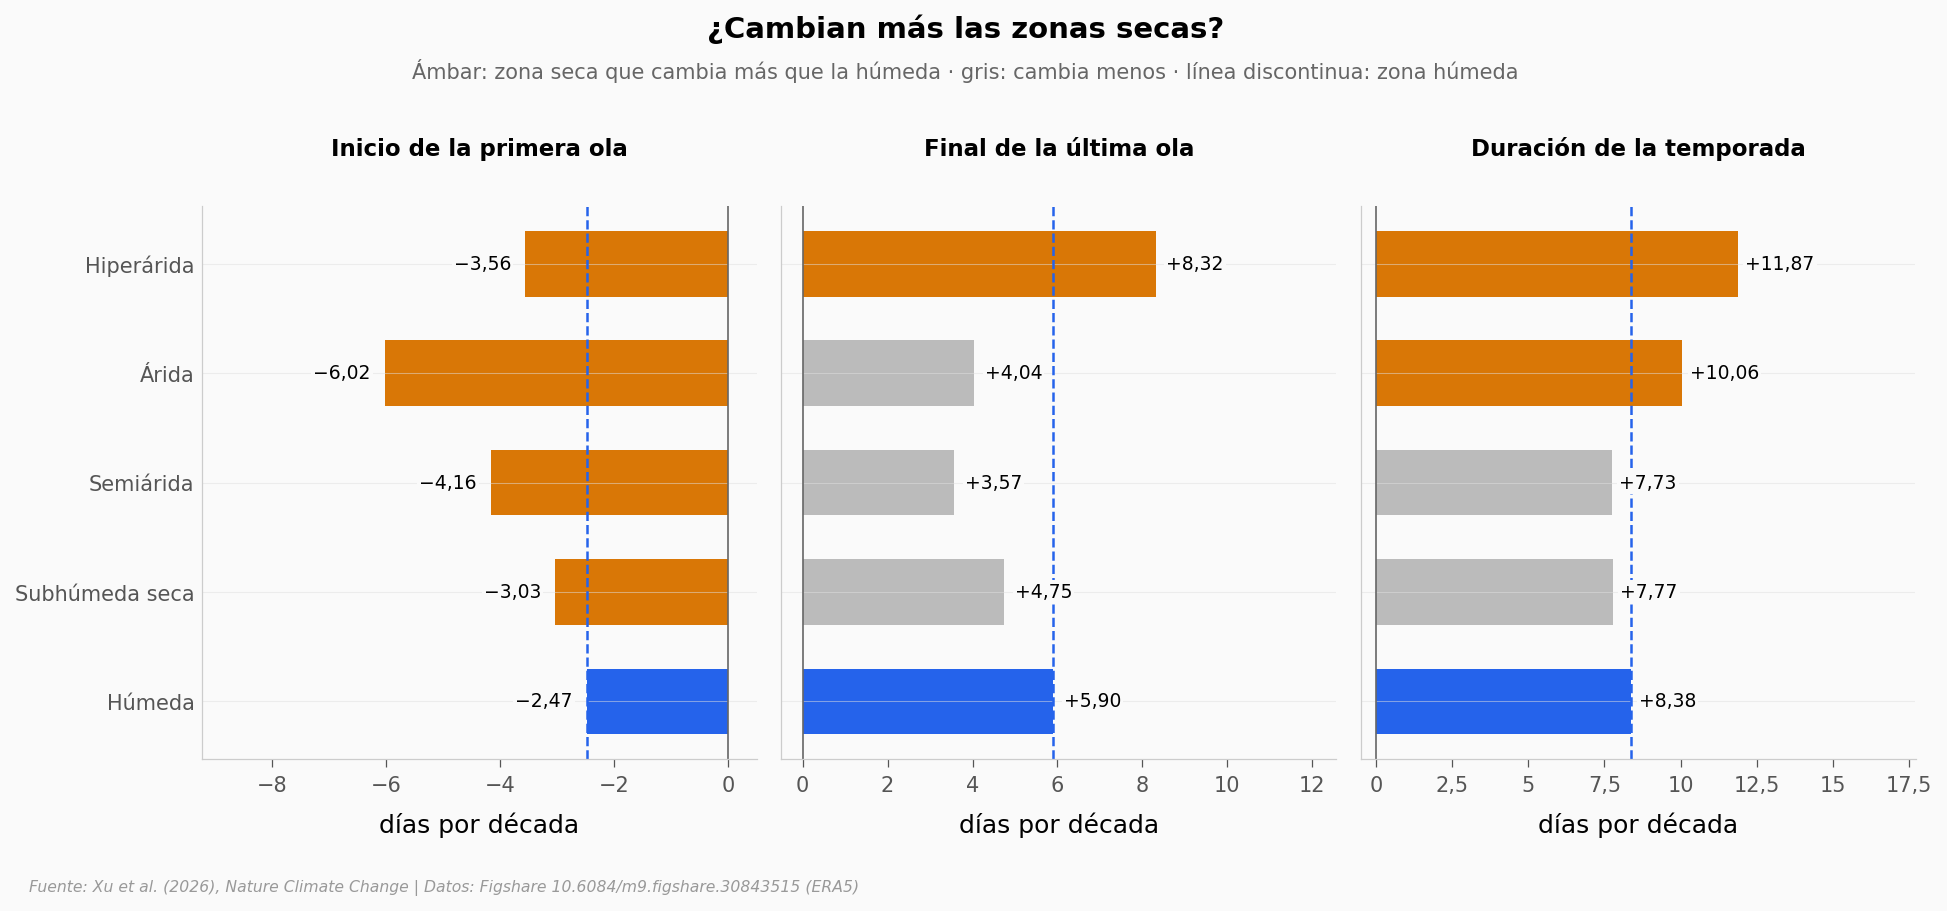

Inicio de la primera ola: 4 de 4 zonas secas superan a la húmeda (-2,47) → Hiperárida, Árida, Semiárida, Subhúmeda seca
Final de la última ola: 1 de 4 zonas secas superan a la húmeda (+5,90) → Hiperárida
Duración de la temporada: 2 de 4 zonas secas superan a la húmeda (+8,38) → Hiperárida, Árida
Hiperárida, temporada: 25,5 → 64,1 días (×2,51)


In [3]:
orden = ['Hiperárida', 'Árida', 'Semiárida', 'Subhúmeda seca', 'Húmeda']
metricas = [('inicio_dia_del_anio', 'Inicio de la primera ola'),
            ('fin_dia_del_anio', 'Final de la última ola'),
            ('temporada_dias', 'Duración de la temporada')]
tab = {}
for col, _ in metricas:
    tab[col] = [tendencia(zonas[zonas.zona == z].anio_centro_ventana15, zonas[zonas.zona == z][col])[0] for z in orden]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
for ax, (col, titulo) in zip(axes, metricas):
    vals = tab[col]
    ref = vals[-1]
    colores = [COLOR_REFERENCIA if abs(v) > abs(ref) else COLOR_CONTEXTO for v in vals[:-1]] + [COLOR_DATOS]
    ax.barh(range(len(orden)), vals, color=colores, height=0.6)
    ax.axvline(ref, color=COLOR_DATOS, lw=1.2, ls='--')
    ax.axvline(0, color='#666666', lw=0.8)
    for i, v in enumerate(vals):
        ax.text(v + (0.25 if v > 0 else -0.25), i, es(f'{v:+.2f}').replace('-', '−'), va='center',
                ha='left' if v > 0 else 'right', fontsize=9, zorder=5,
                bbox=dict(facecolor='#FAFAFA', edgecolor='none', pad=1))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: es(f'{v:g}').replace('-', '−')))
    ax.set_xlim(min(0, min(vals)) * 1.45 - 0.5, max(0, max(vals)) * 1.45 + 0.5)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('días por década')
axes[0].set_yticks(range(len(orden)))
axes[0].set_yticklabels(orden)
axes[0].invert_yaxis()
plt.tight_layout()
fig.suptitle('¿Cambian más las zonas secas?', fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, 'Ámbar: zona seca que cambia más que la húmeda · gris: cambia menos · línea discontinua: zona húmeda',
         fontsize=10, color='#666666', ha='center')
fig.text(0.02, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/zonas_aridez.png', dpi=200, bbox_inches='tight')
plt.show()

for col, titulo in metricas:
    mas = [z for z, v in zip(orden[:-1], tab[col][:-1]) if abs(v) > abs(tab[col][-1])]
    pr(f'{titulo}: {len(mas)} de 4 zonas secas superan a la húmeda ({es(f"{tab[col][-1]:+.2f}")}) → {", ".join(mas)}')
h = zonas[zonas.zona == 'Hiperárida'].sort_values('anio_centro_ventana15')
pr(f'Hiperárida, temporada: {h.temporada_dias.iloc[0]:.1f} → {h.temporada_dias.iloc[-1]:.1f} días (×{h.temporada_dias.iloc[-1] / h.temporada_dias.iloc[0]:.2f})')

La frase del paper se sostiene completa solo para el **inicio**: las cuatro zonas secas adelantan más su primera ola que la húmeda (de −3,03 a −6,02 días por década, frente a −2,47). Y la que más adelanta es la árida, no la hiperárida.

Para el **final** la historia cambia: solo la zona hiperárida (+8,32) se retrasa más que la húmeda (+5,90). Las otras tres zonas secas quedan por debajo. Para la **temporada**, mitad y mitad: la hiperárida (+11,87) y la árida (+10,06) superan a la húmeda (+8,38), la semiárida (+7,73) y la subhúmeda seca (+7,77) no.

El caso extremo es el desierto más seco: en la zona hiperárida la temporada pasa de 25,5 a 64,1 días, 2,51 veces más larga.

## ¿Cuánto de esto es señal y cuánto es ruido?

Un promedio global puede esconder mucha variación. Veamos punto por punto de la rejilla: ¿en qué parte de la tierra va la tendencia en la misma dirección, y en qué parte se distingue del azar?

Inicio más temprano: 72,0 % en esa dirección · 13,4 % p<0,05 · 0,4 % tras FDR
Final más tardío: 79,6 % en esa dirección · 20,3 % p<0,05 · 4,7 % tras FDR
Temporada más larga: 92,1 % en esa dirección · 34,4 % p<0,05 · 13,5 % tras FDR


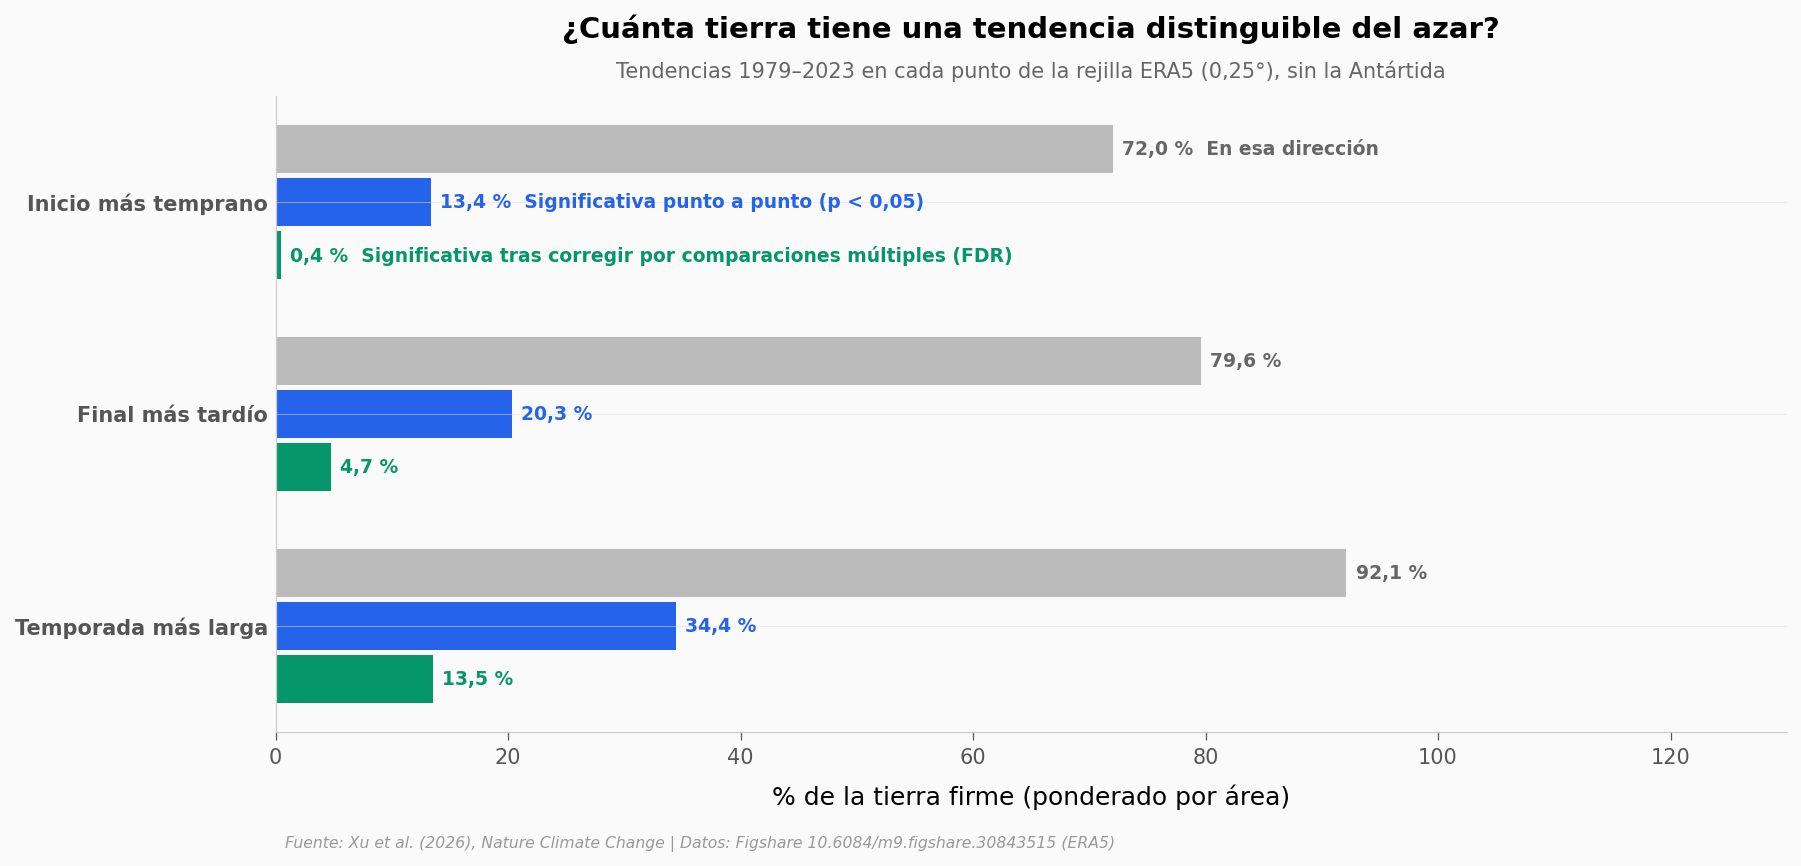

In [4]:
filas = [('inicio', 'negativa', 'Inicio más temprano'),
         ('fin', 'positiva', 'Final más tardío'),
         ('temporada', 'positiva', 'Temporada más larga')]
cols = [('pct_tierra_todas', 'En esa dirección', COLOR_CONTEXTO),
        ('pct_tierra_sig_local_p005', 'Significativa punto a punto (p < 0,05)', COLOR_DATOS),
        ('pct_tierra_sig_FDR_q005', 'Significativa tras corregir por comparaciones múltiples (FDR)', COLOR_SECUNDARIO)]

fig, ax = plt.subplots(figsize=(13, 5.5))
alto = 0.25
for i, (m, signo, etiqueta) in enumerate(filas):
    r = fracc[(fracc.metrica == m) & (fracc.region == 'Global') & (fracc.tendencia == signo)].iloc[0]
    for j, (c, nombre, color) in enumerate(cols):
        y = i + (j - 1) * alto
        ax.barh(y, r[c], height=alto * 0.9, color=color)
        txt = es(f'{r[c]:.1f}') + ' %'
        if i == 0:
            txt += '  ' + nombre
        ax.text(r[c] + 0.8, y, txt, va='center', fontsize=9, color=color if j else '#666666',
                fontweight='bold')
    pr(f'{etiqueta}: {r.pct_tierra_todas:.1f} % en esa dirección · {r.pct_tierra_sig_local_p005:.1f} % p<0,05 · {r.pct_tierra_sig_FDR_q005:.1f} % tras FDR')
ax.set_yticks(range(len(filas)))
ax.set_yticklabels([f[2] for f in filas], fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 130)
ax.set_xlabel('% de la tierra firme (ponderado por área)')
ax.set_title('¿Cuánta tierra tiene una tendencia distinguible del azar?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tendencias 1979–2023 en cada punto de la rejilla ERA5 (0,25°), sin la Antártida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/significancia_tierra.png', dpi=200, bbox_inches='tight')
plt.show()

La dirección es muy mayoritaria: el inicio se adelanta en el **72,0 %** de la tierra, el final se retrasa en el **79,6 %** y la temporada se alarga en el **92,1 %**.

Cuando el abstract dice que la tendencia es "estadísticamente significativa" en el 13,4 %, 20,3 % y 34,4 % de la tierra, habla de cada punto por separado, con p < 0,05. Con cientos de miles de puntos, si no hubiera ninguna tendencia real, alrededor de un 5 % saldría "significativo" por puro azar (la mitad en cada dirección). La corrección por comparaciones múltiples de Benjamini-Hochberg (FDR, tasa de falsos descubrimientos) ajusta eso, y la propia Tabla Suplementaria 2 del paper la trae: queda en **0,4 %, 4,7 % y 13,5 %**.

Punto por punto, la señal es ruidosa. Su fuerza está en que la mayor parte de la tierra firme, entre el 72 % y el 92 % según la métrica, empuja en la misma dirección.

## ¿Qué tan generalizado es el alargamiento?

Pasemos de la media global a la distribución completa: la tendencia de la temporada en cada punto de la tierra.

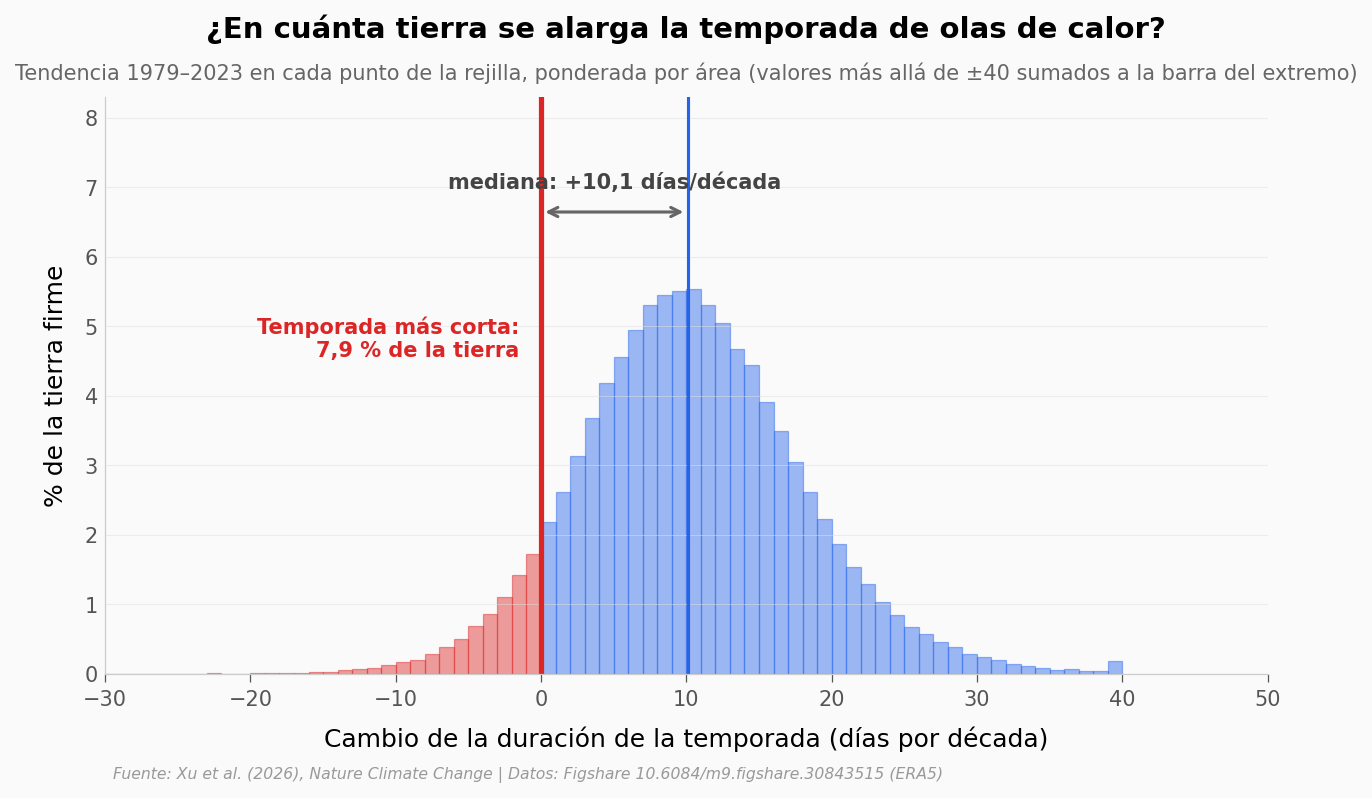

Mediana por punto: +10,1 días/década (IQR +5,3 a +15,1)
Tierra con temporada más corta: 7,9 %


In [5]:
centros = (hist.bin_izq_dias_decada + hist.bin_der_dias_decada) / 2
peso = hist.temporada_pct_area / hist.temporada_pct_area.sum()
acum = np.cumsum(peso.values)
p25, mediana, p75 = np.interp([0.25, 0.5, 0.75], acum, hist.bin_der_dias_decada)
pct_neg = 100 * peso[hist.bin_der_dias_decada <= 0].sum()

fig, ax = plt.subplots(figsize=(10, 5))
colores = [COLOR_ALERTA if c < 0 else COLOR_DATOS for c in centros]
ax.bar(centros, 100 * peso, width=1, color=colores, alpha=0.45, edgecolor=colores, linewidth=0.6)
y_max = 100 * peso.max() * 1.5
ax.set_ylim(0, y_max)
ax.axvline(0, color=COLOR_ALERTA, lw=2.5)
ax.axvline(mediana, color=COLOR_DATOS, lw=1.5)
ax.annotate('', xy=(mediana, y_max * 0.8), xytext=(0, y_max * 0.8),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mediana / 2, y_max * 0.84, f'mediana: {es(f"{mediana:+.1f}")} días/década', ha='center', fontsize=10,
        color='#444444', fontweight='bold')
ax.text(-1.5, y_max * 0.55, f'Temporada más corta:\n{es(f"{pct_neg:.1f}")} % de la tierra', ha='right',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax.set_xlim(-30, 50)
ax.set_xlabel('Cambio de la duración de la temporada (días por década)')
ax.set_ylabel('% de la tierra firme')
ax.set_title('¿En cuánta tierra se alarga la temporada de olas de calor?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tendencia 1979–2023 en cada punto de la rejilla, ponderada por área (valores más allá de ±40 sumados a la barra del extremo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_temporada.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'Mediana por punto: {mediana:+.1f} días/década (IQR {p25:+.1f} a {p75:+.1f})')
pr(f'Tierra con temporada más corta: {pct_neg:.1f} %')

La mediana es **+10,1 días por década**, con la mitad central de la tierra entre +5,3 y +15,1: una distribución ancha, pero casi entera a la derecha del cero. Solo un **7,9 %** de la tierra acorta su temporada.

Ojo: esta mediana por punto (+10,1) no es la misma cifra que la tendencia del promedio global (+8,71). Una explicación probable: cada punto ajusta su recta solo con los años en que tuvo olas, y la tierra con al menos una ola cambió mucho de un año a otro. Veámoslo.

In [6]:
area = tipos.set_index('anio').area_afectada_pct_tierra
pr(f'Tierra con al menos una ola en la ventana: {area.loc[1979]:.1f} % (1979) → {area.loc[2023]:.1f} % (2023); mínimo {area.min():.1f} % en {area.idxmin()}')

# ¿Inicios más rápidos? Fracción de primeras olas de inicio rápido DENTRO del área con olas
for a, b in [(1979, 2000), (2001, 2023), (1979, 2023)]:
    t = tipos[(tipos.anio >= a) & (tipos.anio <= b)]
    r = stats.linregress(t.anio, t.rapido_pct_area_afectada)
    pr(f'Inicio rápido {a}–{b}: media {t.rapido_pct_area_afectada.mean():.1f} %, pendiente {10 * r.slope:+.2f} ± {10 * r.stderr:.2f} puntos por década (p = {r.pvalue:.2g}, n = {len(t)})')

# ¿Depende del año en que empezamos a contar?
for a in [1995, 2000, 2001, 2003, 2005]:
    t = tipos[tipos.anio >= a]
    r = stats.linregress(t.anio, t.rapido_pct_area_afectada)
    pr(f'  Desde {a}: {10 * r.slope:+.2f} puntos por década (p = {r.pvalue:.2g}, n = {len(t)})')

Tierra con al menos una ola en la ventana: 52,2 % (1979) → 96,0 % (2023); mínimo 43,1 % en 1985
Inicio rápido 1979–2000: media 15,1 %, pendiente -0,58 ± 0,36 puntos por década (p = 0,13, n = 22)
Inicio rápido 2001–2023: media 15,4 %, pendiente +0,46 ± 0,19 puntos por década (p = 0,026, n = 23)
Inicio rápido 1979–2023: media 15,3 %, pendiente +0,09 ± 0,11 puntos por década (p = 0,4, n = 45)
  Desde 1995: +0,42 puntos por década (p = 0,004, n = 29)
  Desde 2000: +0,55 puntos por década (p = 0,0068, n = 24)
  Desde 2001: +0,46 puntos por década (p = 0,026, n = 23)
  Desde 2003: +0,40 puntos por década (p = 0,094, n = 21)
  Desde 2005: +0,26 puntos por década (p = 0,35, n = 19)


La tierra con al menos una ola pasó del **52,2 % en 1979 al 96,0 % en 2023**. Y sobre las olas "más rápidas" del título: dentro del área con olas, la fracción de primeras olas que llegan de golpe es plana en todo el periodo (+0,09 puntos por década, p = 0,40). Desde 2001 sube +0,46 ± 0,19 puntos por década (p = 0,026, n = 23 años), aunque depende del año de corte: si se empieza en 2003, ya no baja de p < 0,05 (p = 0,09). El abstract lo llama un giro reciente; en estos datos es pequeño y frágil: no un cambio de régimen.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El inicio de la primera ola se adelanta 3,29 ± 0,12 días por década | ✅ | Replicado exacto desde las medias móviles de Figshare. El ± trata como independientes 31 ventanas que se solapan: es optimista |
| El final de la última ola se retrasa 5,41 ± 0,12 días por década | ✅ | Replicado exacto; mismo aviso sobre el ± |
| La temporada se alarga 8,71 ± 0,17 días por década | ✅ | Replicado exacto: de 33,3 a 60,7 días entre las ventanas centradas en 1986 y 2016 |
| Inicio más temprano, final más tardío y temporada más larga en el 72,0 %, 79,6 % y 92,1 % de la tierra | ✅ | Leído del resumen de fracciones por punto de 0,25° (ponderado por área); coincide con el abstract |
| Tendencia significativa en el 13,4 %, 20,3 % y 34,4 % de la tierra | ⚠️ | Es p < 0,05 punto por punto. Corrigiendo por comparaciones múltiples (Tabla Suplementaria 2 del paper): 0,4 %, 4,7 % y 13,5 % |
| Las zonas secas cambian más que las húmedas | ⚠️ | Para el inicio, sí (4 de 4 zonas secas). Para el final, solo la hiperárida. Para la temporada, la hiperárida y la árida |
| Giro reciente hacia inicios más rápidos | ⚠️ | Plano en 1979–2023 (p = 0,40); desde 2001, +0,46 ± 0,19 puntos por década (p = 0,026), y sensible al año de corte (desde 2003, p = 0,09). Pequeño y reciente |
| La tierra con al menos una ola pasó del 52,2 % al 96,0 % | ✅ | Coincide con la Nota Suplementaria 1 del paper |

> **Limitaciones:** (1) Es un estudio observacional: el paper no separa cuánto se debe al calentamiento y cuánto a la variabilidad natural. (2) ERA5 es un reanálisis, no una red de termómetros. (3) Las olas fuera de la ventana de búsqueda (mayo–septiembre en el norte, noviembre–marzo en el sur) no cuentan. (4) Figshare publica las medias móviles de 15 años, no la serie anual: el error estándar no se puede recalcular con años independientes. (5) El "día del año" global mezcla los dos hemisferios y no es una fecha del calendario.

## Ahora tú

1. **¿Y en un solo lugar?** La celda siguiente aplica a una estación las mismas reglas del detector de los autores y compara con su salida. ¿Aparece la tendencia global en un punto aislado? Pista: cambia `ESTACION = 'USW'` por `'WH'`, `'USE'`, `'Calif'` o `'CHI'`.
2. **¿Qué pasa si la ola exige 5 días en vez de 3?** Pista: `MIN_DIAS = 5` (la comparación con los autores dejará de cuadrar, y eso es lo esperado).
3. **¿Qué zona del mundo alarga más su temporada?** Pista: `mapa = pd.read_csv('datos/mapa_tendencias_1grado.csv')` y luego `mapa.sort_values('temporada_dias_decada').tail(20)`.

Arizona (EE. UU.): 42 de 45 años con al menos una ola
Inicio igual al de los autores en 45 de 45 años
Inicio: -4,62 días por década (p = 0,28)
Temporada: +15,72 días por década (p = 0,00099)


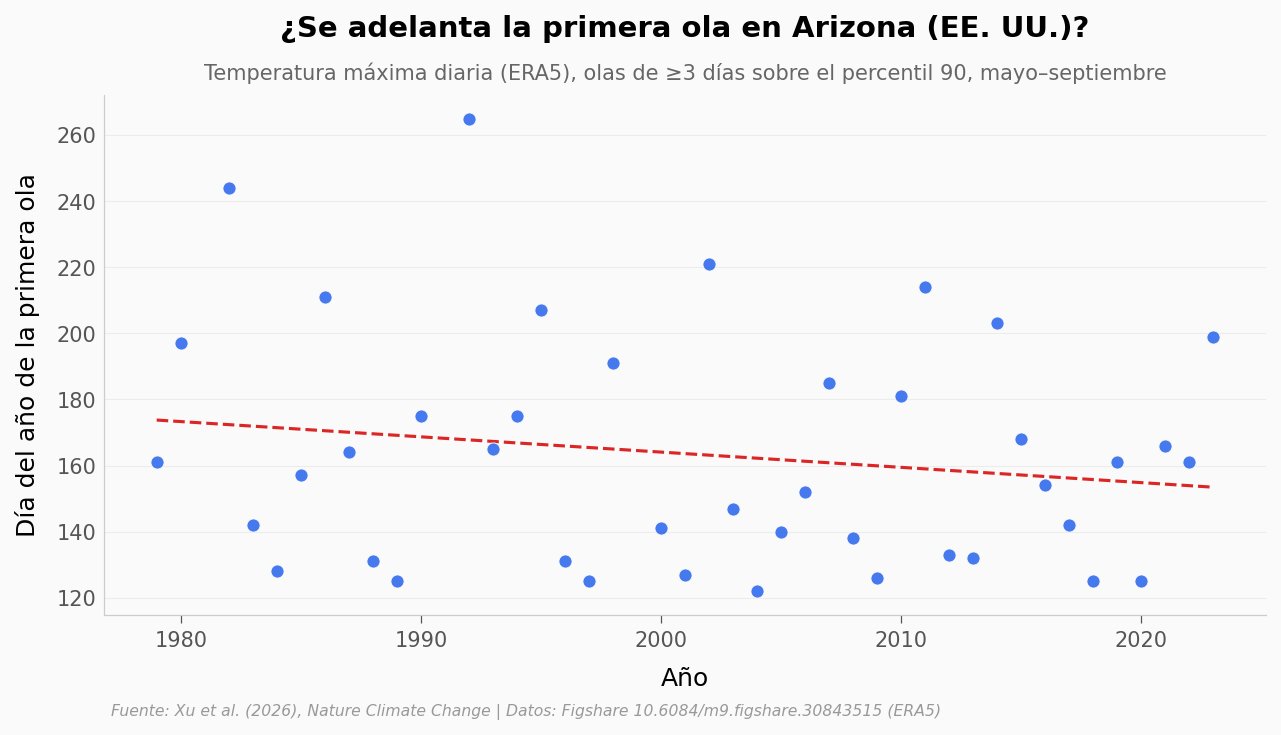

In [7]:
# --- EXPERIMENTA AQUÍ ---
ESTACION = 'USW'     # 'WH' Wuhan · 'USE' Carolina del Sur · 'USW' Arizona · 'Calif' California · 'CHI' Chicago
MIN_DIAS = 3         # días seguidos sobre el umbral para contar una ola
PERCENTIL = 90
VENTANA = (121, 273) # mayo a septiembre (día del año)

t = tmax[f'tmax_C_{ESTACION}'].values
dia = tmax.dia_del_anio.values
anom = t - pd.Series(t).groupby(dia).transform('mean').values          # anomalía frente a la media de ese día
umbral = np.array([np.percentile(anom[(dia >= max(1, d - 7)) & (dia <= min(365, d + 7))], PERCENTIL, method='hazen')
                   for d in range(1, 366)])                           # percentil en ventana de 15 días
caliente = anom > umbral[dia - 1]

filas = []
for anio in range(1979, 2024):
    m = (tmax.anio.values == anio) & (dia >= VENTANA[0]) & (dia <= VENTANA[1])
    c, d = caliente[m], dia[m]
    olas, i = [], 0
    while i < len(c):
        if c[i]:
            j = i
            while j + 1 < len(c) and c[j + 1]:
                j += 1
            if j - i + 1 >= MIN_DIAS:
                olas.append((d[i], d[j]))
            i = j + 1
        else:
            i += 1
    filas.append((anio, olas[0][0] if olas else np.nan, olas[-1][1] if olas else np.nan, len(olas)))
res = pd.DataFrame(filas, columns=['anio', 'inicio', 'fin', 'n_olas'])
res['temporada'] = res.fin - res.inicio + 1

aut = olas_aut[olas_aut.estacion == ESTACION].set_index('anio')
coinciden = sum((np.isnan(a) and np.isnan(b)) or a == b for a, b in zip(res.inicio, aut.inicio_dia_del_anio.values))
nombre = estaciones.set_index('sitename').loc[ESTACION, 'nombre']
pr(f'{nombre}: {res.inicio.notna().sum()} de 45 años con al menos una ola')
pr(f'Inicio igual al de los autores en {coinciden} de 45 años')
con = res.dropna()
for col, etiqueta in [('inicio', 'Inicio'), ('temporada', 'Temporada')]:
    r = stats.linregress(con.anio, con[col])
    pr(f'{etiqueta}: {10 * r.slope:+.2f} días por década (p = {r.pvalue:.2g})')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(con.anio, con.inicio, color=COLOR_DATOS, s=40, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5)
r = stats.linregress(con.anio, con.inicio)
ax.plot(con.anio, r.intercept + r.slope * con.anio, color=COLOR_ALERTA, lw=1.5, ls='--')
ax.set_xlabel('Año')
ax.set_ylabel('Día del año de la primera ola')
ax.set_title(f'¿Se adelanta la primera ola en {nombre}?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Temperatura máxima diaria (ERA5), olas de ≥{MIN_DIAS} días sobre el percentil {PERCENTIL}, mayo–septiembre',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estacion_experimento.png', dpi=200, bbox_inches='tight')
plt.show()

## Créditos

- **Paper:** Xu et al. (2026), *Earlier and faster heatwave onset on land under a warming climate*, Nature Climate Change. DOI: [10.1038/s41558-026-02762-2](https://doi.org/10.1038/s41558-026-02762-2)
- **Datos:** Figshare, [10.6084/m9.figshare.30843515](https://doi.org/10.6084/m9.figshare.30843515) (código del detector, medias móviles, mapas de tendencia y temperatura de estaciones de prueba). Temperatura de base: ERA5, Copernicus Climate Change Service.
- **Notebook:** [El Lab de Ciencia a Mordiscos](https://github.com/Ciencia-a-Mordiscos/lab) · licencia CC BY 4.0.

## Fuentes

**Paper**: [Earlier and faster heatwave onset on land under a warming climate](https://doi.org/10.1038/s41558-026-02762-2)  
*Nature Climate Change, 2026-09-23 · paywall*

**Supplementary Material**: [Supplementary Information for "Earlier and faster heatwave onset on land under a warming climate" (MOESM1: Notes 1–2, Figs. 1–32, Tables 1–3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41558-026-02762-2/MediaObjects/41558_2026_2762_MOESM1_ESM.pdf)  
*Nature Climate Change, 2026-09-23*

**Datos**: [Heatwave Detection Code and Test-Site Temperature Dataset Derived from ERA5 (Xu, W.; v2)](https://doi.org/10.6084/m9.figshare.30843515)  
*Figshare: código del detector, medias móviles de 15 años, mapas de tendencia y temperatura de estaciones de prueba*

**Referencias citadas**: [ERA5 hourly data on single levels from 1940 to present (Hersbach et al.)](https://doi.org/10.24381/cds.adbb2d47)

*23 afirmaciones del notebook verificadas contra estas fuentes*